# Province Prediction Model

This notebook runs the cleaned province-level prediction model.

Workflow:
- change the forecast settings in the next cell
- run the model
- inspect the summary tables and plots
- the full yearly outputs are saved automatically under `outputs/province/`

The most important control is `FORECAST_END_YEAR`, so you can easily project to any other year beyond the current default.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model')
SRC_DIR = PROJECT_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from prediction_model import ModelConfig, OUTPUT_DIR, VEHICLE_TYPES, run_province_model, save_province_outputs

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## Settings

Update these values and rerun the notebook whenever you want a different forecast horizon or a different summary year.

In [2]:
FORECAST_END_YEAR = 2035
SELECTED_YEAR = 2035

config = ModelConfig(
    forecast_end_year=FORECAST_END_YEAR,
    selected_year=SELECTED_YEAR,
)


In [3]:
province_result = run_province_model(config)
province_output_dir = save_province_outputs(province_result, OUTPUT_DIR / "province")
province_output_dir


PosixPath('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/outputs/province')

## Summary Table

In [4]:
province_result["summary_year"]


,count_2035,fleet_share_2035,sales_share_2035
vehicle_type,,,
ice_suv,2.507961e+06,0.460369,0.440445
ice_van/pickup,9.791260e+05,0.179731,0.18747
electric,8.062949e+05,0.148006,0.175631
hev_suv,7.517015e+05,0.137985,0.167877
ice_sedan,2.413869e+05,0.044310,0.0
hev_sedan,1.612453e+05,0.029599,0.028577


## Stock Controls

In [5]:
province_result["future_stock_controls"].tail(10)


,future_turnover_rate,future_population_growth,target_total_fleet
2026,0.080162,-0.001059,5.003604e+06
2027,0.080162,0.009493,5.051105e+06
2028,0.080162,0.009493,5.099058e+06
2029,0.080162,0.009493,5.147465e+06
2030,0.080162,0.009493,5.196332e+06
2031,0.080162,0.009493,5.245663e+06
2032,0.080162,0.009493,5.295463e+06
2033,0.080162,0.009493,5.345735e+06
2034,0.080162,0.009493,5.396484e+06
2035,0.080162,0.009493,5.447715e+06


## Sales Share by Year

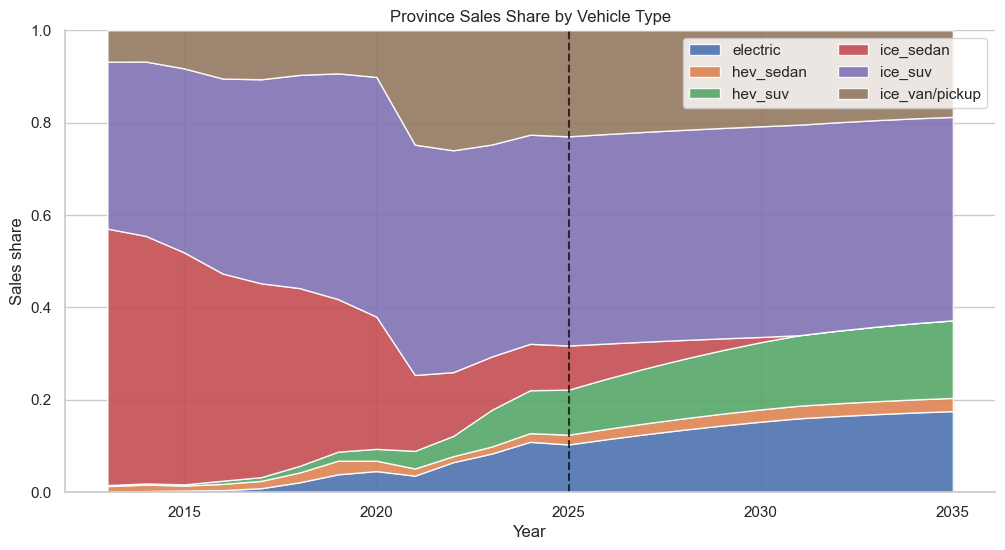

In [9]:
sales_df = province_result["sales_share_by_year"].copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(sales_df.index, [sales_df[col] for col in VEHICLE_TYPES], labels=VEHICLE_TYPES, alpha=0.9)
ax.axvline(config.observed_share_end_year, color="black", linestyle="--", alpha=0.7)
ax.set_title("Province Sales Share by Vehicle Type")
ax.set_xlabel("Year")
ax.set_ylabel("Sales share")
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc="upper right")
plt.show()


## Fleet Market Share by Year

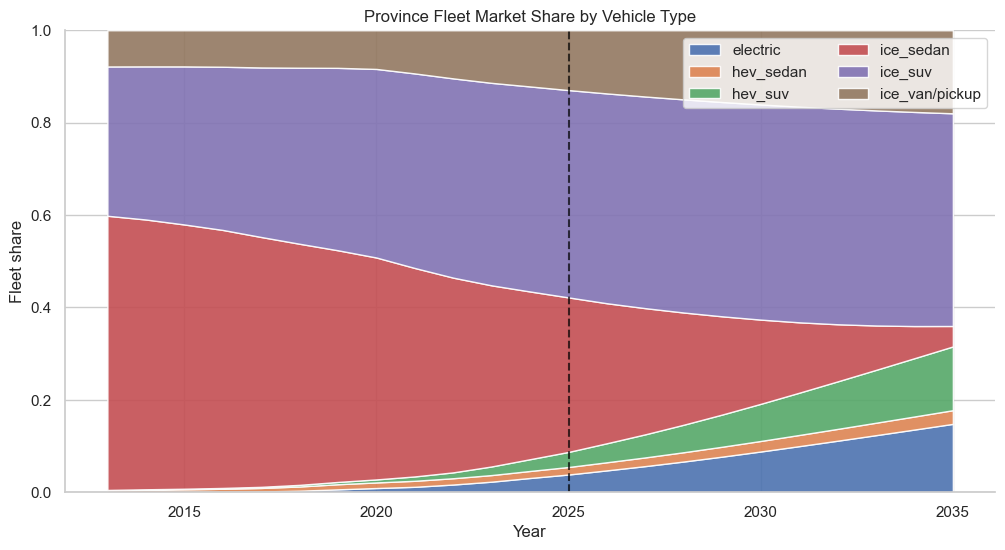

In [ ]:
fleet_share_df = province_result["fleet_share_by_year"].copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(fleet_share_df.index, [fleet_share_df[col] for col in VEHICLE_TYPES], labels=VEHICLE_TYPES, alpha=0.9)
ax.axvline(config.observed_share_end_year, color="black", linestyle="--", alpha=0.7)
ax.set_title("Province Fleet Share by Vehicle Type")
ax.set_xlabel("Year")
ax.set_ylabel("Fleet share")
ax.set_ylim(0, 1)
ax.legend(ncol=2, loc="upper right")
plt.show()


## Total Vehicle Counts by Year

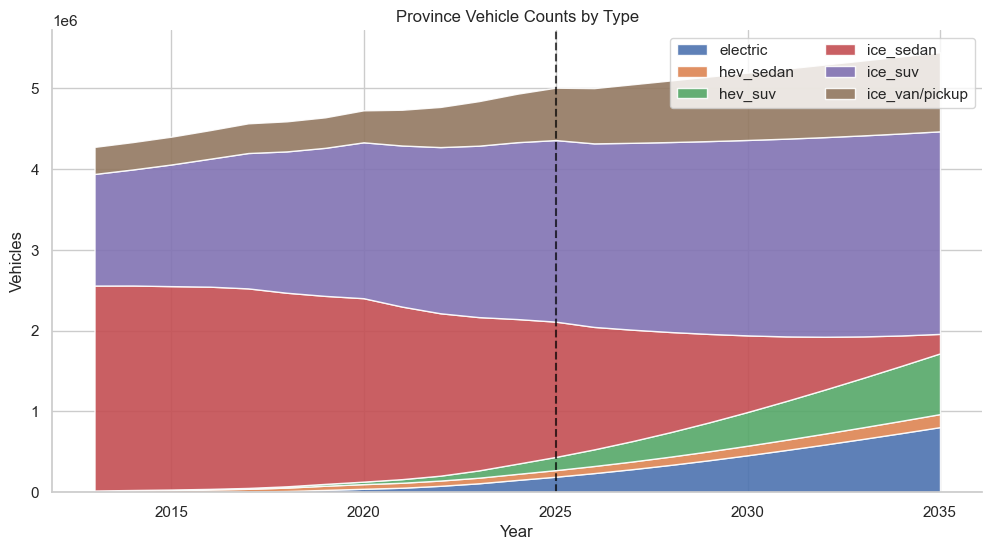

In [8]:
count_df = province_result["vehicle_counts_by_year"].copy()
fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(count_df.index, [count_df[col] for col in VEHICLE_TYPES], labels=VEHICLE_TYPES, alpha=0.9)
ax.axvline(config.observed_share_end_year, color="black", linestyle="--", alpha=0.7)
ax.set_title("Province Vehicle Counts by Type")
ax.set_xlabel("Year")
ax.set_ylabel("Vehicles")
ax.legend(ncol=2, loc="upper right")
plt.show()


## Output Files

In [ ]:
sorted(path.name for path in province_output_dir.iterdir())
